# ABACBS conference 2025

Here contain codes for figures and tables generated for ABACBS conference.

## Import modules and functions

In [22]:
import modules.atlas_handle as ah
from Bio import SeqIO
import sys, os, re
import pandas as pd
import logomaker
import modules.analysis_utils as analysis_utils
from IPython.display import display
from plotnine import (ggplot, aes, geom_histogram, geom_density, theme_bw, 
                      labs, theme, element_text, scale_x_continuous, geom_vline, 
                      geom_boxplot, geom_jitter, scale_x_discrete, stat_summary,
                      scale_y_continuous, scale_fill_manual, scale_color_manual, geom_hline,
                      element_blank)
import matplotlib.pyplot as plt
import numpy as np
import typing as t
from Bio.Seq import Seq
import json
import statistics
 

Generate CRISPR-Cas atlas summary table

In [2]:
atlas_json_file = "/spacers_db/crispr-cas-atlas/crispr-cas-atlas-v1.0-VI.jsonl"

def protein_length_filt(prot_len: int) -> bool:
    if 900 <= prot_len <= 1800:
        return True
    return False


df = pd.DataFrame(columns=["operon_id", "biosample_id", "species", "spacers"])

with open("/spacers_db/crispr-cas-atlas/crispr-cas-atlas-v1.0-VI.jsonl", "r") as f:
    records = [json.loads(line) for line in f]
    for rec in records:
        if rec.get("metadata", {}).get("assembly_type") == "Genome":
            cas_genes = rec.get("cas" , [])
            for cas in cas_genes:
                if (cas.get("gene_name") == "Cas13b") and (protein_length_filt(cas.get("length"))):
                    new_row = {
                        "operon_id": rec.get("operon_id"),
                        "biosample_id": rec.get("metadata", {}).get("biosample_id"),
                        "species": rec.get("metadata", {}).get("sample_name"),
                        "spacers": rec.get("summary").get("n_spacers") - 1
                    }
                    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

# out_csv_file = "abacbs2025/data/crispr_cas_atlas_Cas13b_summary.csv"
# df.to_csv("crispr_cas_atlas_Cas13b_summary.csv", index=False)

Summarise data avaliable

In [9]:
cas13b_summary_file = "abacbs2025/data/crispr_cas_atlas_Cas13b_summary_edit.csv"

df = pd.read_csv(cas13b_summary_file, header=0)

display(df.describe())

,spacers
count,370.000000
mean,10.924324
std,6.967575
min,2.000000
25%,6.000000
50%,10.000000
75%,14.000000
max,61.000000


In [3]:
atlas_json_file = "/spacers_db/crispr-cas-atlas/crispr-cas-atlas-v1.0-VI.jsonl"
cas13b_summary_file = "abacbs2025/data/crispr_cas_atlas_Cas13b_summary_edit.csv"

def retrieve_spacers(json_file: str, operon_id: str) -> t.List[str]:
    with open(json_file, "r") as f:
        records = [json.loads(line) for line in f]
        for rec in records:
            if rec.get("operon_id") == operon_id:
                spacers = rec.get("crispr", {})[0].get("crispr_spacers", [])
                cleaned = list(filter(None, spacers))
    return cleaned


df = pd.read_csv(cas13b_summary_file, header=0)

species_spacers = {}

for index, row in df.iterrows():
    spacers_list = species_spacers.get(row["species"], [])
    retrieved_spacers = retrieve_spacers(atlas_json_file, row["operon_id"])
    spacers_list.extend(retrieved_spacers)
    species_spacers[row["species"]] = spacers_list


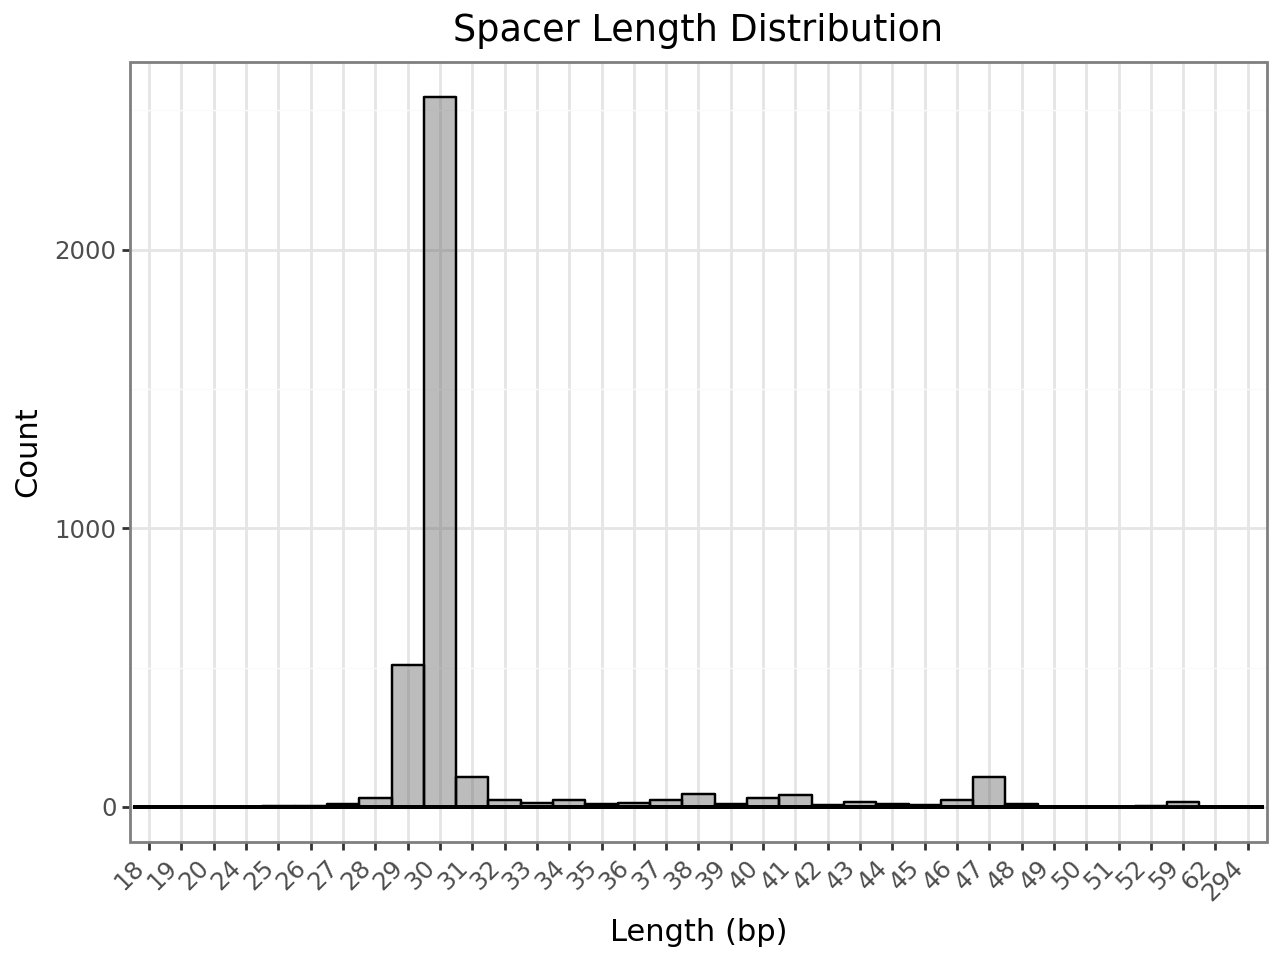

In [4]:
all_spacers = []

for species, spacers in species_spacers.items():
    all_spacers.extend(spacers)

df = pd.DataFrame(columns=["spacer", "length"])
for spacer in all_spacers:
    new_row = {
        "spacer": spacer,
        "length": len(spacer)
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

p_freq = (ggplot(df, aes(x='length')) +
    geom_histogram(binwidth=1, position="identity", alpha=0.4, color="black") +
    # scale_x_continuous(breaks=range(0, int(df["length"].max()) + 1, 1)) +
    theme_bw() +
    labs(title='Spacer Length Distribution',
        x='Length (bp)',
        y='Count') +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
    )

display(p_freq)

## Sequence motif analysis 

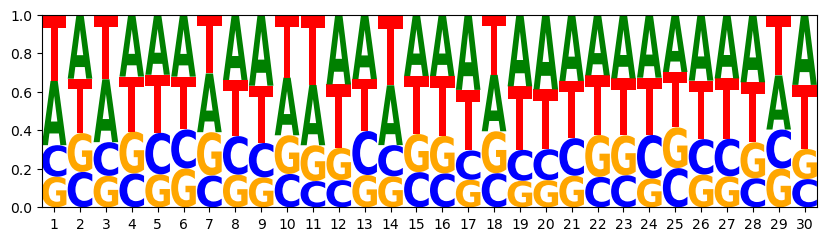

In [4]:
length = 30

all_spacers = []

for species, spacers in species_spacers.items():
    filtered_spacers = [s for s in spacers if len(s) == length]
    all_spacers.extend(filtered_spacers)

counts_matrix = logomaker.alignment_to_matrix(sequences=all_spacers)
prob_matrix = logomaker.transform_matrix(counts_matrix, from_type='counts', to_type='probability', pseudocount=0)
logo = logomaker.Logo(prob_matrix)
logo.ax.set_xticks(range(prob_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, prob_matrix.shape[0] + 1))

plt.show()

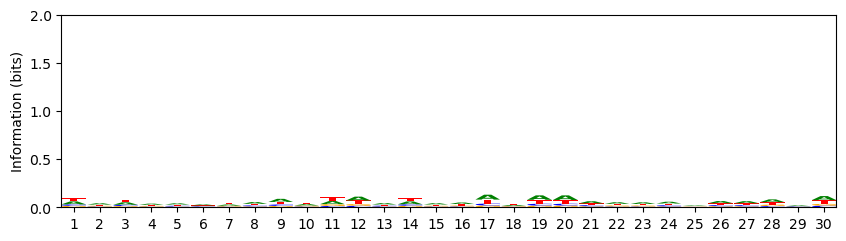

In [76]:
info_matrix = logomaker.transform_matrix(prob_matrix, from_type='probability', to_type='information')
logo = logomaker.Logo(info_matrix)
logo.ax.set_ylabel("Information (bits)")
logo.ax.set_ylim(0, 2)  # Max info per position in DNA is 2 bits
logo.ax.set_xticks(range(info_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, info_matrix.shape[0] + 1))

plt.show()

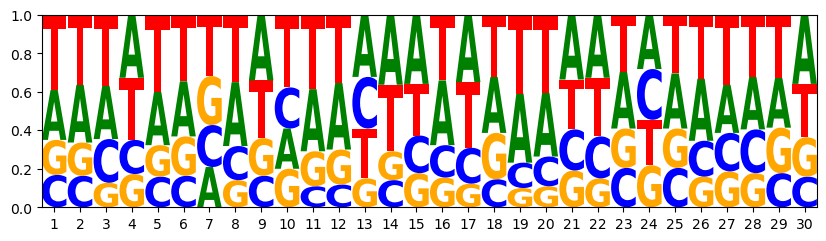

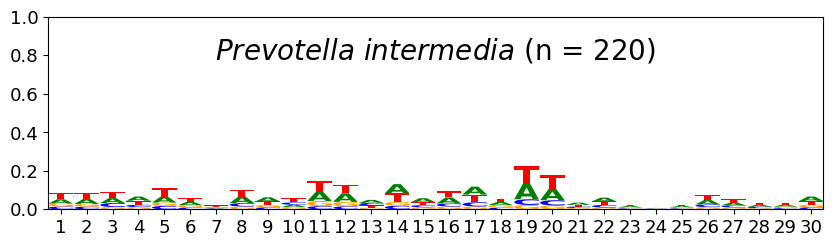

In [19]:
species = "Prevotella intermedia"

spacers = species_spacers.get(species, [])
filtered_spacers = [s for s in spacers if len(s) == length]

counts_matrix = logomaker.alignment_to_matrix(sequences=filtered_spacers)
prob_matrix = logomaker.transform_matrix(counts_matrix, from_type='counts', to_type='probability', pseudocount=0)
logo = logomaker.Logo(prob_matrix)
logo.ax.set_xticks(range(prob_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, prob_matrix.shape[0] + 1))

# plt.title(f"{species} spacer sequences (n={len(filtered_spacers)})")
# plt.show()

info_matrix = logomaker.transform_matrix(prob_matrix, from_type='probability', to_type='information')
logo = logomaker.Logo(info_matrix)
logo.ax.set_ylabel("")
logo.ax.set_ylim(0, 1)  # Max info per position in DNA is 2 bits
logo.ax.set_xticks(range(info_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, info_matrix.shape[0] + 1))
logo.ax.tick_params(axis='both', labelsize=13)

# Save file (before plt.show)
output_file = f"/home/unimelb.edu.au/rbengtsson/work/spacer_analysis/abacbs2025/figs/{species.replace(' ', '_')}_motif.png"


# --- TITLE INSIDE PLOT ---

# plt.title(r"$\it{" + species.replace(' ', r"}\ \it{") + "}$" + f" (n = {len(filtered_spacers)})", fontsize=18)
logo.ax.text(
    0.5, 0.90,
    r"$\it{" + species.replace(' ', r"}\ \it{") + "}$" + f" (n = {len(filtered_spacers)})",
    ha='center', va='top', fontsize=20,
    transform=logo.ax.transAxes
)
plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()

In [5]:
atlas_json_file = "/spacers_db/crispr-cas-atlas/crispr-cas-atlas-v1.0-VI.jsonl"
cas13b_summary_file = "abacbs2025/data/crispr_cas_atlas_Cas13b_summary_edit.csv"
out_file = "abacbs2025/data/crispr_cas_atlas_Cas13b_protein.fasta"

def get_protein_seqs(operon_id: str, json_file:str) -> str:

    selection_criteria = {
    "gene_name": "Cas13b",
    "truncated": "00"
}
        
    with open(json_file, "r") as f:
        records = [json.loads(line) for line in f]
        for rec in records:
            if rec.get("operon_id") == operon_id:
                for cas in rec.get('cas', []):
                    if cas['gene_name'] == selection_criteria['gene_name'] and cas['truncated'] == selection_criteria['truncated']:
                        return cas.get("protein")



df = pd.read_csv(cas13b_summary_file, header=0)

with open(out_file, "w") as out_f:
    for index, row in df.iterrows():
        prot_seq = get_protein_seqs(row["operon_id"], atlas_json_file)
        if prot_seq:
            header = f">{row['operon_id']}"
            out_f.write(f"{header}\n{prot_seq}\n")

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f995c5d8580>>
Traceback (most recent call last):
  File "/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


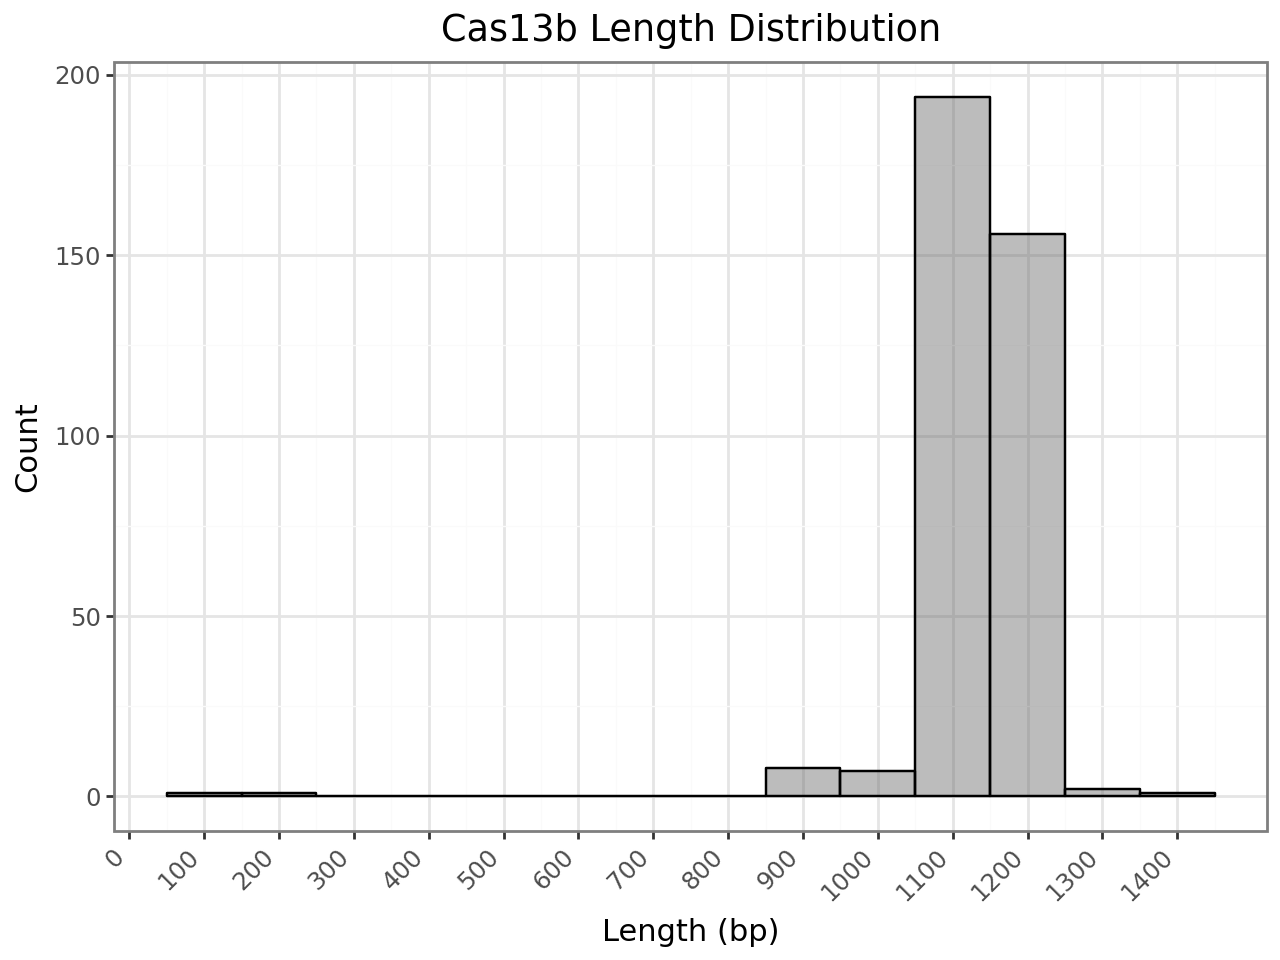

In [2]:
fassta_file = "abacbs2025/data/crispr_cas_atlas_Cas13b_protein.fasta"

protein_len_df = pd.DataFrame(columns=["operon_id", "length"])

for record in SeqIO.parse(fassta_file, "fasta"):
    new_row = {
        "operon_id": record.id,
        "length": len(record.seq)
    }
    protein_len_df = pd.concat([protein_len_df, pd.DataFrame([new_row])], ignore_index=True)

# Ensure numeric dtype
protein_len_df["length"] = pd.to_numeric(protein_len_df["length"], errors="coerce").astype("Int64")
protein_len_df = protein_len_df.dropna(subset=["length"]).astype({"length": "int64"})

p_freq = (ggplot(protein_len_df, aes(x='length')) +
    geom_histogram(binwidth=100, position="identity", alpha=0.4, color="black") +
    scale_x_continuous(breaks=range(0, int(protein_len_df["length"].max()) + 100, 100)) +
    theme_bw() +
    labs(title='Cas13b Length Distribution',
        x='Length (bp)',
        y='Count') +
    theme(axis_text_x=element_text(rotation=45, hjust=1))
    )

display(p_freq)

In [ ]:
cd-hit -i abacbs2025/data/crispr_cas_atlas_Cas13b_protein.fasta \
-o abacbs2025/data/Cas13b_protein_cd-hit_80i_90c \
-c 0.8 \
-n 4 \
-g 1 \
-G 0 \
-aS 0.9 \
-d 0 \
-p 1 \
-T 4 \
-M 0 > abacbs2025/data/Cas13b_protein_cd-hit_80i_90c.log

In [19]:
cluster_file = "abacbs2025/data/Cas13b_protein_cd-hit_80i_90c.clstr"

def count_clusters(clstr_file: str) -> dict:
    cluster_dict = {}

    with open(clstr_file, 'r') as inf:
        for line in inf:
            line = line.strip()
            if line.startswith('>'):
                cluster_num = line.split()[-1]
            elif (line.endswith('*')) or (line.endswith('%')):
                accn_list = cluster_dict.get(cluster_num, [])
                fields = re.split(r'[,\t ]+', line)
                accn = fields[2].lstrip(' >').replace('...', '')
                accn_list.append(accn)
                cluster_dict[cluster_num] = accn_list

    return cluster_dict

for cluster_num, accns in count_clusters(cluster_file).items():
    if (len(accns) > 5):
        print(f"Cluster {cluster_num}: {len(accns)} sequences")

Cluster 4: 16 sequences
Cluster 5: 11 sequences
Cluster 6: 34 sequences
Cluster 8: 6 sequences
Cluster 13: 61 sequences
Cluster 21: 7 sequences
Cluster 30: 7 sequences
Cluster 39: 43 sequences
Cluster 45: 8 sequences
Cluster 46: 7 sequences
Cluster 47: 12 sequences
Cluster 51: 32 sequences
Cluster 56: 52 sequences
Cluster 57: 6 sequences


In [17]:
def get_cluster_species(cluster_accns: t.List[str], summary_df: pd.DataFrame) -> t.List[str]:
    species_list = []
    for accn in cluster_accns:
        species = summary_df.loc[summary_df['operon_id'] == accn, 'species']
        if not species.empty:
            species_list.append(species.values[0])
        
    return list(set(species_list))


summary_df = pd.read_csv(cas13b_summary_file, header=0)


for cluster_num, accns in count_clusters(cluster_file).items():
    if (len(accns) > 5):
        species = get_cluster_species(accns,summary_df)
        print(f"Cluster {cluster_num} species:")
        for s in species:
            print(f" - {s}")

Cluster 4 species:
 - Flavobacterium columnare
 - Flavobacterium covae
Cluster 5 species:
 - Capnocytophaga stomatis
 - Capnocytophaga cynodegmi
 - Capnocytophaga canimorsus
 - Bergeyella zoohelcum
Cluster 6 species:
 - Flavobacterium columnare
Cluster 8 species:
 - Flavobacterium columnare
 - Flavobacterium oreochromis
Cluster 13 species:
 - Porphyromonas sp.
 - Porphyromonas gulae
 - Porphyromonas gingivalis
Cluster 21 species:
 - Myroides odoratimimus
 - Myroides sp.
Cluster 30 species:
 - Prevotella intermedia
 - Prevotella pleuritidis
Cluster 39 species:
 - Porphyromonas gulae
 - Porphyromonas gingivalis
Cluster 45 species:
 - Prevotella intermedia
Cluster 46 species:
 - Prevotella intermedia
 - Prevotella pallens
Cluster 47 species:
 - Prevotella intermedia
 - Prevotella aurantiaca
Cluster 51 species:
 - Porphyromonas gulae
 - Porphyromonas gingivalis
Cluster 56 species:
 - Riemerella anatipestifer
Cluster 57 species:
 - Prevotella sp.
 - Prevotella buccae


In [69]:
cas13b_summary_file = "abacbs2025/data/crispr_cas_atlas_Cas13b_summary_edit.csv"

cluster_num = "5"
operon_id_list = count_clusters(cluster_file).get(cluster_num)

df = pd.read_csv(cas13b_summary_file, header=0)

filtered = df[df['operon_id'].isin(operon_id_list)]

pd.set_option('display.max_rows', None)

print(len(filtered))

# display(filtered)

11


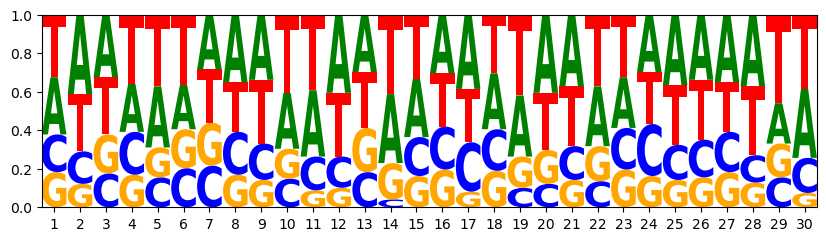

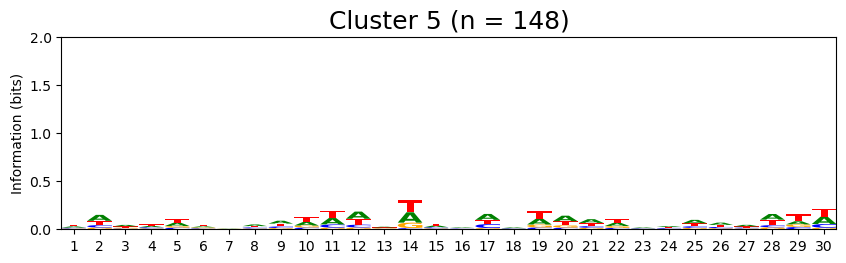

In [79]:
cluster_num = "5"
operon_id_list = count_clusters(cluster_file).get(cluster_num)

df = pd.read_csv(cas13b_summary_file, header=0)

filtered = df[df['operon_id'].isin(operon_id_list)]


clstr_spacers_list = []

for operon_id in operon_id_list:
    spacers = retrieve_spacers(atlas_json_file, operon_id)
    clstr_spacers_list.extend(spacers)

filtered_spacers = [s for s in clstr_spacers_list if len(s) == 30]

counts_matrix = logomaker.alignment_to_matrix(sequences=filtered_spacers)
prob_matrix = logomaker.transform_matrix(counts_matrix, from_type='counts', to_type='probability', pseudocount=0)
logo = logomaker.Logo(prob_matrix)
logo.ax.set_xticks(range(prob_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, prob_matrix.shape[0] + 1))

# plt.title(f"Cluster {cluster_num} spacer sequences (n={len(filtered_spacers)})")
# plt.show()

info_matrix = logomaker.transform_matrix(prob_matrix, from_type='probability', to_type='information')
logo = logomaker.Logo(info_matrix)
logo.ax.set_ylabel("Information (bits)")
logo.ax.set_ylim(0, 2)  # Max info per position in DNA is 2 bits
logo.ax.set_xticks(range(info_matrix.shape[0]))
logo.ax.set_xticklabels(range(1, info_matrix.shape[0] + 1))

# Save file (before plt.show)
output_file = f"/home/unimelb.edu.au/rbengtsson/work/spacer_analysis/abacbs2025/figs/Cluster_{cluster_num}_motif.png"

plt.title(f"Cluster {cluster_num} (n = {len(filtered_spacers)})", fontsize=18)
plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()



## Protospacer acquisition position

In [ ]:
# Run spacer BLASTn script
python3 abacbs2025/scripts/spacer_blastn.py

# Generate summary results table
python3 abacbs2025/scripts/generate_blastn_meta.py

# Remove redundant hits and combine results
python3 abacbs2025/scripts/compile_results.py

In [62]:
blastn_results_file = "abacbs2025/data/spacer_phageblastn_results_90id_95cov_23-10-2025.csv"

df_blastn = pd.read_csv(blastn_results_file, header=0)

critera = {
    "pident": 100,
    "algn_length": 30,
    "completeness": "High-quality"
}

filtered_blastn = df_blastn[
    (df_blastn['pident'] >= critera['pident']) &
    (df_blastn['algn_length'] >= critera['algn_length']) &
    (df_blastn['completeness'] == critera['completeness'])
].copy()

display(filtered_blastn['spacerhost'].value_counts())

spacerhost
Porphyromonas gingivalis             112
Prevotella intermedia                104
Riemerella anatipestifer              68
Flavobacterium columnare              45
Prevotella buccae                     16
Porphyromonas gulae                   12
Bacteroides pyogenes                   8
Prevotella sp.                         7
Chryseobacterium jejuense              4
Prevotella pectinovora                 4
Flavobacterium sp.                     2
Flavobacterium jumunjinense            2
Capnocytophaga canis                   2
Chryseobacterium phosphatilyticum      2
Empedobacter stercoris                 1
Capnocytophaga canimorsus              1
Porphyromonas sp.                      1
Prevotella aurantiaca                  1
Name: count, dtype: int64

104


/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 2 rows containing missing values.


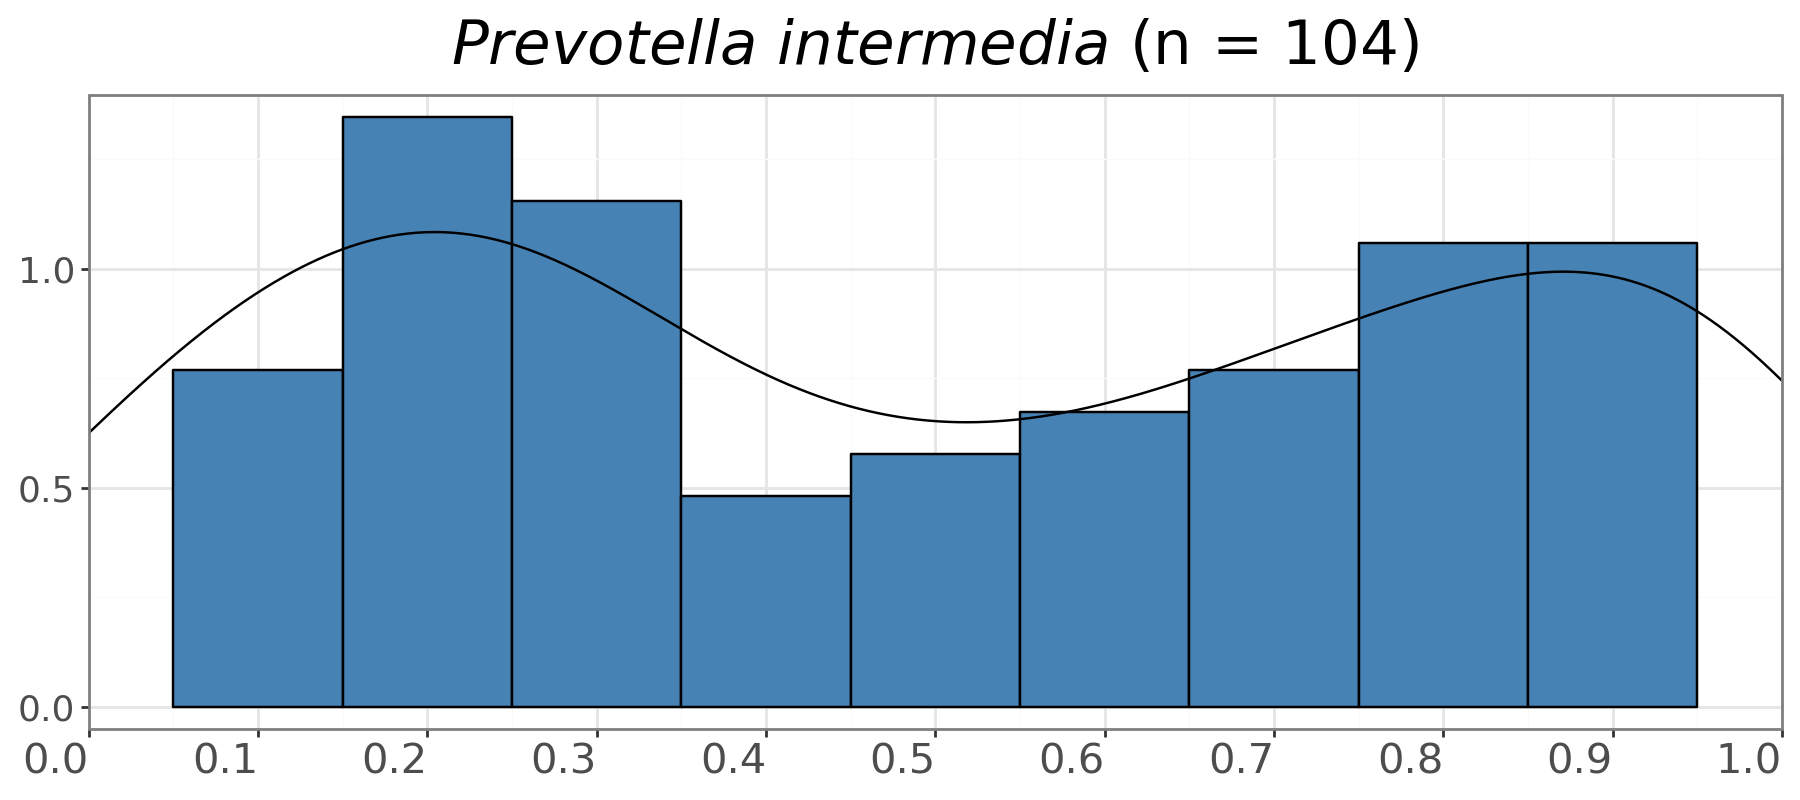

In [32]:
from itertools import count
from plotnine import after_stat, element_blank


blastn_results_file = "abacbs2025/data/spacer_phageblastn_results_90id_95cov_23-10-2025.csv"

df_blastn = pd.read_csv(blastn_results_file, header=0)

# print(len(df_blastn['sequence_id'].unique()))

species = "Prevotella intermedia"

critera = {
    "spacerhost": f"{species}",
    "pident": 100,
    "algn_length": 30,
    "completeness": "High-quality"
}

filtered_blastn = df_blastn[
    (df_blastn['spacerhost'] == critera['spacerhost']) &
    (df_blastn['pident'] >= critera['pident']) &
    (df_blastn['algn_length'] >= critera['algn_length']) &
    (df_blastn['completeness'] == critera['completeness'])
].copy()


filtered_blastn['relative_pos'] = (
    ((filtered_blastn['phagestart'] + filtered_blastn['phageend']) / 2)
    / filtered_blastn['phagelength']
)

pd.set_option('display.max_rows', None)

print(len(filtered_blastn))
# # display(filtered_blastn)

p_freq = (
    ggplot(filtered_blastn, aes(x='relative_pos')) +
    geom_histogram(aes(y='..density..'), 
                   binwidth=0.1, 
                   position="identity", 
                   fill="steelblue", color="black") +
    geom_density(alpha=0.6) +
    scale_y_continuous(limits=(0, None), expand=(0, 0.05)) +
    scale_x_continuous(
    limits=(0, 1),
    breaks=np.arange(0, 1.1, 0.1),
    expand=(0, 0)) +
    theme_bw() +
    labs(
        title=r"$\it{" + species.replace(' ', r'}\ \it{') + "}$" + f" (n = {len(filtered_blastn)})"
    ) +
    theme(
        figure_size=(9, 4),
        plot_title=element_text(size=22),      # only affects main title
        axis_text_x=element_text(hjust=1, size=15),
        axis_text_y=element_text(size=13),
        axis_title_x=element_blank(),
        axis_title_y=element_blank()
    )
)

# output_file = f"/home/unimelb.edu.au/rbengtsson/work/spacer_analysis/abacbs2025/figs/{species.replace(' ', '_')}_positions.png"
# p_freq.save(output_file, dpi=300, width=9, height=4, bbox_inches='tight')
display(p_freq)


Separate by clusters

In [16]:
cluster_dict = count_clusters(cluster_file)

for cluster_num, accns in count_clusters(cluster_file).items():
    if (len(accns) > 5):
        print(f"Cluster {cluster_num}: {len(accns)} sequences")

Cluster 4: 16 sequences
Cluster 5: 11 sequences
Cluster 6: 34 sequences
Cluster 8: 6 sequences
Cluster 13: 61 sequences
Cluster 21: 7 sequences
Cluster 30: 7 sequences
Cluster 39: 43 sequences
Cluster 45: 8 sequences
Cluster 46: 7 sequences
Cluster 47: 12 sequences
Cluster 51: 32 sequences
Cluster 56: 52 sequences
Cluster 57: 6 sequences


/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 9 x 2 in image.
/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /home/unimelb.edu.au/rbengtsson/work/spacer_analysis/abacbs2025/figs/Cluster_51_positions.png
/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 2 rows containing missing values.
/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 2 rows containing missing values.


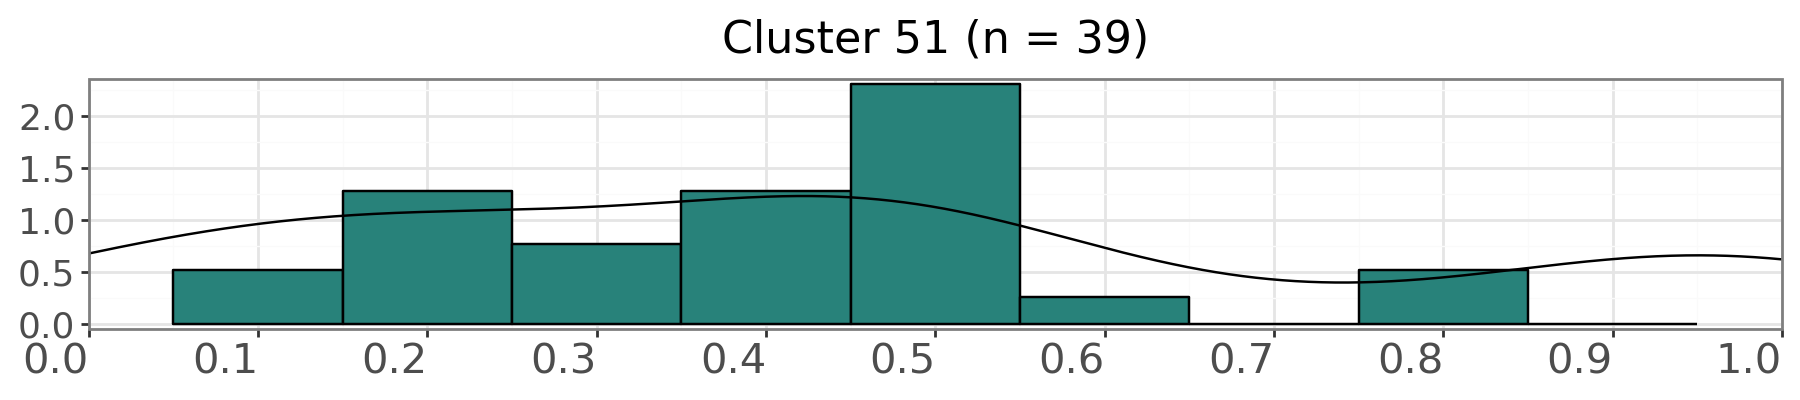

In [45]:
blastn_results_file = "abacbs2025/data/spacer_phageblastn_results_90id_95cov_23-10-2025.csv"
df_blastn = pd.read_csv(blastn_results_file, header=0)

cluster_num = "51"
operon_id_list = count_clusters(cluster_file).get(cluster_num)

def retrieve_operon_ids(sequence_id: str) -> str:
    operon_id = '_'.join(sequence_id.split('_')[:2])
    return operon_id


critera = {
    "operon_id": operon_id_list,
    "pident": 100,
    "algn_length": 30,
    "completeness": "High-quality"
}

filtered_blastn = df_blastn[
    # (df_blastn['sequence_id'].isin(critera['operon_id'])) &
    (df_blastn['sequence_id'].str.split('_').str[:2].str.join('_').isin(critera['operon_id'])) &
    (df_blastn['pident'] >= critera['pident']) &
    (df_blastn['algn_length'] >= critera['algn_length']) &
    (df_blastn['completeness'] == critera['completeness'])
].copy()

filtered_blastn['relative_pos'] = (
    ((filtered_blastn['phagestart'] + filtered_blastn['phageend']) / 2)
    / filtered_blastn['phagelength']
)


pd.set_option('display.max_rows', None)

# display(filtered_blastn)

p_freq = (
    ggplot(filtered_blastn, aes(x='relative_pos')) +
    geom_histogram(aes(y='..density..'), 
                   binwidth=0.1, 
                   position="identity", 
                   fill="#28827A", color="black") +
    geom_density(alpha=0.6) +
    scale_y_continuous(limits=(0, None), expand=(0, 0.05)) +
    scale_x_continuous(
    limits=(0, 1),
    breaks=np.arange(0, 1.1, 0.1),
    expand=(0, 0)) +
    theme_bw() +
    labs(
        title=r"Cluster " + f"{cluster_num} (n = {len(filtered_blastn)})"
    ) +
    theme(
        figure_size=(9, 2),
        plot_title=element_text(size=16),      # only affects main title
        axis_text_x=element_text(hjust=1, size=15),
        # axis_text_x=element_blank(),
        axis_text_y=element_text(size=13),
        axis_title_x=element_blank(),
        axis_title_y=element_blank()
    )
)

output_file = f"/home/unimelb.edu.au/rbengtsson/work/spacer_analysis/abacbs2025/figs/Cluster_{cluster_num}_positions.png"
p_freq.save(output_file, dpi=300, width=9, height=2, bbox_inches='tight')

display(p_freq)

# print(len(filtered_blastn))
# print(display(filtered_blastn))